In [1]:
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Patch
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap, BoundaryNorm
import cartopy.crs as ccrs
import cartopy.feature as cf
import easygems.healpix as egh
import intake
import yaml
from pathlib import Path
import warnings
from matplotlib.backends.backend_agg import FigureCanvasAgg as FigureCanvas
warnings.filterwarnings('ignore')

In [2]:
def load_config(config_file, catalog_source):
    """
    Load configuration from YAML file for a specific catalog source.
    
    Args:
        config_file: str
            Path to the YAML configuration file
        catalog_source: str
            The catalog source key to load configuration for
            
    Returns:
        dict: Configuration dictionary for the specified source
    """
    with open(config_file, 'r') as f:
        config = yaml.safe_load(f)
    
    if catalog_source not in config:
        raise ValueError(f"Catalog source '{catalog_source}' not found in config file. "
                        f"Available sources: {list(config.keys())}")
    
    return config[catalog_source]

In [3]:
# Catalog parameters
catalog_file = "https://digital-earths-global-hackathon.github.io/catalog/catalog.yaml"


config_file = Path("/global/homes/f/feng045/program/waccem/gsrm_cooccurrencefeature/config/config_sources.yaml")
catalog_source = "scream_ne120"

# Load configuration for the specified source
config = load_config(config_file, catalog_source)

source_name = config.get('source_name')
catalog_location = config.get('catalog_location', 'NERSC')
catalog_params = config.get('catalog_params', {}).copy()
varname_precip_liq = config.get('varname_precip_liq')
varname_precip_ice = config.get('varname_precip_ice')
pr_convert_factor = config.get('pr_convert_factor')
start_datetime = config.get('start_datetime')
end_datetime = config.get('end_datetime')

In [4]:


source_name = "scream"
# source_name = "IMERGv7"
# source_name = "icon_d3hp003"
# source_name = "casesm2_10km_nocumulus"
zoom = 8

root_dir = f"/pscratch/sd/w/wcmca1/hackathon/"
mask_dir = f"{root_dir}/cof_masks/{source_name}_cofmasks_hp8_v1.zarr"

figdir = f"/global/cfs/cdirs/m1867/zfeng/hk25/quicklooks_cof/tmp/"
os.makedirs(figdir, exist_ok=True)

# Load the COF mask dataset
print(f"Loading COF mask data from: {mask_dir}")
ds = xr.open_zarr(mask_dir, mask_and_scale=False, consolidated=True)
ds = ds.pipe(egh.attach_coords)
ds

Loading COF mask data from: /pscratch/sd/w/wcmca1/hackathon//cof_masks/scream_cofmasks_hp8_v1.zarr


<xarray.Dataset> Size: 104GB
Dimensions:                  (time: 1577, cell: 786432)
Coordinates:
  * time                     (time) datetime64[ns] 13kB 2019-08-01 ... 2020-0...
    crs                      int64 8B 0
  * cell                     (cell) int64 6MB 0 1 2 3 ... 786429 786430 786431
    lat                      (cell) float64 6MB 0.1492 0.2984 ... -0.1492
    lon                      (cell) float64 6MB 45.0 45.18 44.82 ... 314.8 315.0
Data variables: (12/21)
    ar_etc_overlap_mask      (time, cell) float32 5GB dask.array<chunksize=(48, 786432), meta=np.ndarray>
    ar_isolated_mask         (time, cell) float32 5GB dask.array<chunksize=(48, 786432), meta=np.ndarray>
    ar_mask                  (time, cell) float32 5GB dask.array<chunksize=(48, 786432), meta=np.ndarray>
    ar_mcs_etc_overlap_mask  (time, cell) float32 5GB dask.array<chunksize=(48, 786432), meta=np.ndarray>
    ar_mcs_overlap_mask      (time, cell) float32 5GB dask.array<chunksize=(48, 786432), meta=np.ndarray>
    cloud_types              (time, cell) float32 5GB dask.array<chunksize=(48, 786432), meta=np.ndarray>
    ...                       ...
    mcs_etc_overlap_mask     (time, cell) float32 5GB dask.array<chunksize=(48, 786432), meta=np.ndarray>
    mcs_isolated_mask        (time, cell) float32 5GB dask.array<chunksize=(48, 786432), meta=np.ndarray>
    mcs_mask                 (time, cell) float32 5GB dask.array<chunksize=(48, 786432), meta=np.ndarray>
    nd_pr                    (time, cell) float32 5GB dask.array<chunksize=(48, 786432), meta=np.ndarray>
    st_pr                    (time, cell) float32 5GB dask.array<chunksize=(48, 786432), meta=np.ndarray>
    tc_mask                  (time, cell) float32 5GB dask.array<chunksize=(48, 786432), meta=np.ndarray>
Attributes: (12/46)
    Contact:                      Zhe Feng: zhe.feng@pnnl.gov
    Conventions:                  CF-1.8
    Created_on:                   Mon May  5 10:42:36 2025
    Institution:                  Pacific Northwest National Laboratory
    NCO:                          netCDF Operators version 5.3.2 (Homepage = ...
    Title:                        HEALPix remapped tracking mask data (zoom=8)
    ...                           ...
    tc_filtering_threshold:       10%
    threads_per_worker:           1
    thresholds:                   MCS: 20%, AR: 10%, ETC: 5% (2-way), 0% (3-way)
    topography_file:              /lustre/orion/cli115/world-shared/e3sm/inpu...
    username:                     noel
    zoom:                         8

In [5]:
# Extreme precipitation percentiles file
extreme_file = f"{root_dir}/extreme_precip/{source_name}_precip_percentiles_6h_hp8_v1.nc"

# Load the precipitation percentiles dataset
dsx = xr.open_dataset(extreme_file)
dsx

<xarray.Dataset> Size: 25MB
Dimensions:  (cell: 786432)
Coordinates:
  * cell     (cell) int64 6MB 0 1 2 3 4 5 ... 786427 786428 786429 786430 786431
    lat      (cell) float64 6MB ...
    lon      (cell) float64 6MB ...
    crs      int64 8B ...
Data variables:
    pr_p90   (cell) float32 3MB ...
    pr_p95   (cell) float32 3MB ...
Attributes:
    Title:            Precipitation percentiles at different time scales
    contact:          Zhe Feng, zhe.feng@pnnl.gov
    source_name:      scream
    start_date:       2019-08-01T00:00
    end_date:         2020-08-31T23:59
    created_on:       Wed Nov 26 14:47:19 2025
    grid_type:        HEALPix
    zoom_level:       8
    time_duration:    6h
    quantile_method:  linear

### Read in 6 h precipitation with custom sources

In [6]:
# Special treatment for certain datasets not in the catalog
if catalog_source == "IR_IMERG":
    # Special case for IMERG data (not in catalog yet)
    dir_healpix = "/pscratch/sd/w/wcmca1/GPM/healpix/"
    in_basename = f"IMERG_V7_"
    time_res = "6H"
    in_zarr = f"{dir_healpix}{in_basename}{time_res}_zoom{zoom}_20190101_20211231.zarr"
    # Read IMERG dataset
    print(f"Loading IMERG dataset (NOT from catalog): {in_zarr}")
    ds_p = xr.open_zarr(in_zarr, consolidated=True)
    ds_p = ds_p.pipe(egh.attach_coords)

elif catalog_source == "scream_ne120":
    dir_healpix = "/pscratch/sd/w/wcmca1/hackathon/healpix/scream/"
    in_basename = f"scream_pr"
    time_res = "6h"
    in_zarr = f"{dir_healpix}{in_basename}{time_res}_z{zoom}.zarr"
    # Read SCREAM dataset
    print(f"Loading SCREAM dataset (NOT from catalog): {in_zarr}")
    ds_p = xr.open_zarr(in_zarr, consolidated=True)
    ds_p = ds_p.pipe(egh.attach_coords)

elif catalog_source == "nicam_gl11":
    dir_healpix = "/pscratch/sd/w/wcmca1/hackathon/healpix/nicam_gl11/shifted/"
    in_basename = f"NICAM_pr"
    time_res = "6h"
    in_zarr = f"{dir_healpix}{in_basename}{time_res}_z{zoom}.zarr"
    # Read NICAM dataset
    print(f"Loading NICAM dataset (NOT from catalog): {in_zarr}")
    ds_p = xr.open_zarr(in_zarr, consolidated=True)
    ds_p = ds_p.pipe(egh.attach_coords)

elif catalog_source == "um_glm_n2560_RAL3p3":
    dir_healpix = "/pscratch/sd/w/wcmca1/hackathon/healpix/um_glm_n2560_RAL3p3/"
    in_basename = f"um_glm_n2560_RAL3p3_pr"
    time_res = "6h"
    in_zarr = f"{dir_healpix}{in_basename}{time_res}_z{zoom}.zarr"
    # Read UM dataset
    print(f"Loading UM dataset (NOT from catalog): {in_zarr}")
    ds_p = xr.open_zarr(in_zarr, consolidated=True)
    ds_p = ds_p.pipe(egh.attach_coords)

elif catalog_source == "casesm2_10km_nocumulus":
    dir_healpix = "/pscratch/sd/w/wcmca1/hackathon/healpix/casesm2_10km_nocumulus/"
    in_basename = f"casesm2_10km_nocumulus_pr"
    time_res = "6h"
    in_zarr = f"{dir_healpix}{in_basename}{time_res}_z{zoom}.zarr"
    # Read CASESM2 dataset
    print(f"Loading CASESM2 dataset (NOT from catalog): {in_zarr}")
    ds_p = xr.open_zarr(in_zarr, consolidated=True)
    ds_p = ds_p.pipe(egh.attach_coords)

else:
    # Load the HEALPix catalog
    print(f"Loading HEALPix catalog: {catalog_file}")
    in_catalog = intake.open_catalog(catalog_file)
    if catalog_location:
        in_catalog = in_catalog[catalog_location]
    
    # Get the DataSet from the catalog
    ds_p = in_catalog[catalog_source](**catalog_params).to_dask()
    # Add lat/lon coordinates to the HEALPix DataSet
    ds_p = ds_p.pipe(egh.attach_coords)

# Check liquid precipitaiton variable
if varname_precip_liq in list(ds_p.keys()):
    # Convert liquid precipitation to mm/h
    pr = ds_p[varname_precip_liq] * pr_convert_factor
# Check if the ice precipitation variable exist in the dataset
if varname_precip_ice in list(ds_p.keys()):
    # Convert ice precipitation to liquid equivalent
    prs = ds_p[varname_precip_ice] * pr_convert_factor
    # Add ice precipitation to get total precipitation
    pr = pr + prs

pr

Loading SCREAM dataset (NOT from catalog): /pscratch/sd/w/wcmca1/hackathon/healpix/scream/scream_pr6h_z8.zarr


<xarray.DataArray 'pr' (time: 1589, cell: 786432)> Size: 5GB
dask.array<mul, shape=(1589, 786432), dtype=float32, chunksize=(28, 786432), chunktype=numpy.ndarray>
Coordinates:
    lat      (cell) float64 6MB 0.1492 0.2984 0.2984 ... -0.2984 -0.2984 -0.1492
    lon      (cell) float64 6MB 45.0 45.18 44.82 45.0 ... 315.2 314.8 315.0
  * time     (time) datetime64[ns] 13kB 2019-08-01 ... 2020-09-01
    crs      int64 8B 0
  * cell     (cell) int64 6MB 0 1 2 3 4 5 ... 786427 786428 786429 786430 786431

In [7]:
def create_union_mask(mask_list):
    """
    Create a union mask from multiple mask variables.
    
    The union operation is applied on the spatial (cell) dimension only, 
    preserving any time or other dimensions in the input masks.
    
    Parameters:
    -----------
    mask_list : list of xarray.DataArray
        List of mask DataArrays to combine. Each mask can contain track IDs (integers > 0)
        or binary values (0 or 1). Masks will be converted to binary before combining.
        All masks should have the same dimensions (e.g., time and cell).
    
    Returns:
    --------
    xarray.DataArray
        Binary mask (0 or 1 as float) representing the union of all input masks.
        A pixel is 1 if it appears in any of the input masks at that time, 0 otherwise.
        The output preserves all dimensions from the input (e.g., time, cell).
    
    Example:
    --------
    >>> # Create union of 3-way overlap masks (with time dimension)
    >>> union_mask = create_union_mask([
    ...     ds.mcs_ar_etc_overlap_mask,  # shape: (time: 3138, cell: 786432)
    ...     ds.ar_mcs_etc_overlap_mask,
    ...     ds.etc_mcs_ar_overlap_mask
    ... ])
    >>> # Result shape: (time: 3138, cell: 786432)
    
    >>> # Create union for single timestep
    >>> union_mask_single = create_union_mask([
    ...     ds.mcs_ar_overlap_mask.sel(time='2020-01-01'),
    ...     ds.ar_etc_overlap_mask.sel(time='2020-01-01')
    ... ])
    
    >>> # Create union of all 2-way overlaps over time range
    >>> all_2way = create_union_mask([
    ...     ds.mcs_ar_overlap_mask.sel(time=slice('2020-01', '2020-02')),
    ...     ds.ar_etc_overlap_mask.sel(time=slice('2020-01', '2020-02')),
    ...     ds.mcs_etc_overlap_mask.sel(time=slice('2020-01', '2020-02'))
    ... ])
    """
    if not mask_list:
        raise ValueError("mask_list cannot be empty")
    
    # Convert each mask to binary (any value > 0 becomes 1)
    # This operation preserves all dimensions (time, cell, etc.)
    binary_masks = [(mask > 0).astype(float) for mask in mask_list]
    
    # Sum all binary masks element-wise across all dimensions
    # This maintains the shape (e.g., time x cell)
    summed_mask = sum(binary_masks)
    
    # Convert back to binary (any sum > 0 becomes 1)
    # Union at each time step: a cell is 1 if it appears in ANY mask at that time
    union_mask = (summed_mask > 0).astype(float)
    
    return union_mask

print("✅ create_union_mask() function defined")

✅ create_union_mask() function defined


In [8]:
_ds = ds.sel(time='2020-01-01T00:00:00')
_ds

<xarray.Dataset> Size: 85MB
Dimensions:                  (cell: 786432)
Coordinates:
    time                     datetime64[ns] 8B 2020-01-01
    crs                      int64 8B 0
  * cell                     (cell) int64 6MB 0 1 2 3 ... 786429 786430 786431
    lat                      (cell) float64 6MB 0.1492 0.2984 ... -0.1492
    lon                      (cell) float64 6MB 45.0 45.18 44.82 ... 314.8 315.0
Data variables: (12/21)
    ar_etc_overlap_mask      (cell) float32 3MB dask.array<chunksize=(786432,), meta=np.ndarray>
    ar_isolated_mask         (cell) float32 3MB dask.array<chunksize=(786432,), meta=np.ndarray>
    ar_mask                  (cell) float32 3MB dask.array<chunksize=(786432,), meta=np.ndarray>
    ar_mcs_etc_overlap_mask  (cell) float32 3MB dask.array<chunksize=(786432,), meta=np.ndarray>
    ar_mcs_overlap_mask      (cell) float32 3MB dask.array<chunksize=(786432,), meta=np.ndarray>
    cloud_types              (cell) float32 3MB dask.array<chunksize=(786432,), meta=np.ndarray>
    ...                       ...
    mcs_etc_overlap_mask     (cell) float32 3MB dask.array<chunksize=(786432,), meta=np.ndarray>
    mcs_isolated_mask        (cell) float32 3MB dask.array<chunksize=(786432,), meta=np.ndarray>
    mcs_mask                 (cell) float32 3MB dask.array<chunksize=(786432,), meta=np.ndarray>
    nd_pr                    (cell) float32 3MB dask.array<chunksize=(786432,), meta=np.ndarray>
    st_pr                    (cell) float32 3MB dask.array<chunksize=(786432,), meta=np.ndarray>
    tc_mask                  (cell) float32 3MB dask.array<chunksize=(786432,), meta=np.ndarray>
Attributes: (12/46)
    Contact:                      Zhe Feng: zhe.feng@pnnl.gov
    Conventions:                  CF-1.8
    Created_on:                   Mon May  5 10:42:36 2025
    Institution:                  Pacific Northwest National Laboratory
    NCO:                          netCDF Operators version 5.3.2 (Homepage = ...
    Title:                        HEALPix remapped tracking mask data (zoom=8)
    ...                           ...
    tc_filtering_threshold:       10%
    threads_per_worker:           1
    thresholds:                   MCS: 20%, AR: 10%, ETC: 5% (2-way), 0% (3-way)
    topography_file:              /lustre/orion/cli115/world-shared/e3sm/inpu...
    username:                     noel
    zoom:                         8

In [9]:
# Original masks
mcs_mask = _ds['mcs_mask']
ar_mask = _ds['ar_mask']
etc_mask = _ds['etc_mask']
tc_mask = _ds['tc_mask']
cloud_types = _ds['cloud_types']

# Isolated masks
mcs_isolated_mask = _ds['mcs_isolated_mask']
ar_isolated_mask = _ds['ar_isolated_mask']
etc_isolated_mask = _ds['etc_isolated_mask']

# Co-occurrence masks
# Create union of 2-way overlap masks
mcs_ar_2way_mask = create_union_mask([
    _ds['mcs_ar_overlap_mask'],
    _ds['ar_mcs_overlap_mask'],
])
mcs_etc_2way_mask = create_union_mask([
    _ds['mcs_etc_overlap_mask'],
    _ds['etc_mcs_overlap_mask'],
])
ar_etc_2way_mask = create_union_mask([
    _ds['ar_etc_overlap_mask'],
    _ds['etc_ar_overlap_mask'],
])
# Create union of 3-way overlap masks
mcs_ar_etc_3way_mask = create_union_mask([
    _ds['mcs_ar_etc_overlap_mask'],
    _ds['ar_mcs_etc_overlap_mask'],
    _ds['etc_mcs_ar_overlap_mask'],
])

<Figure size 640x480 with 0 Axes>

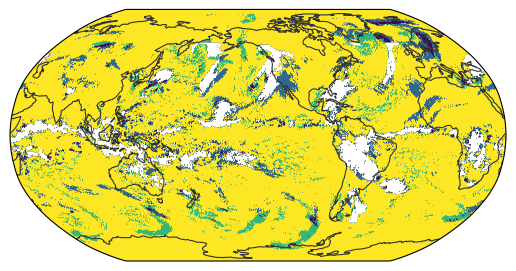

In [10]:
egh.healpix_show(cloud_types)

In [11]:
# Remove all tracked features from cloud_types
cloud_types_cleaned = xr.where(
    ((mcs_isolated_mask > 0) |
    (ar_isolated_mask > 0) |
    (etc_isolated_mask > 0) |
    (tc_mask > 0) |
    (mcs_ar_2way_mask > 0) |
    (mcs_etc_2way_mask > 0) |
    (ar_etc_2way_mask > 0) |
    (mcs_ar_etc_3way_mask > 0)), 0, cloud_types, keep_attrs=True
)

[Text(1, 0, 'DC'), Text(2, 0, 'ND'), Text(3, 0, 'ST'), Text(4, 0, 'DZ')]

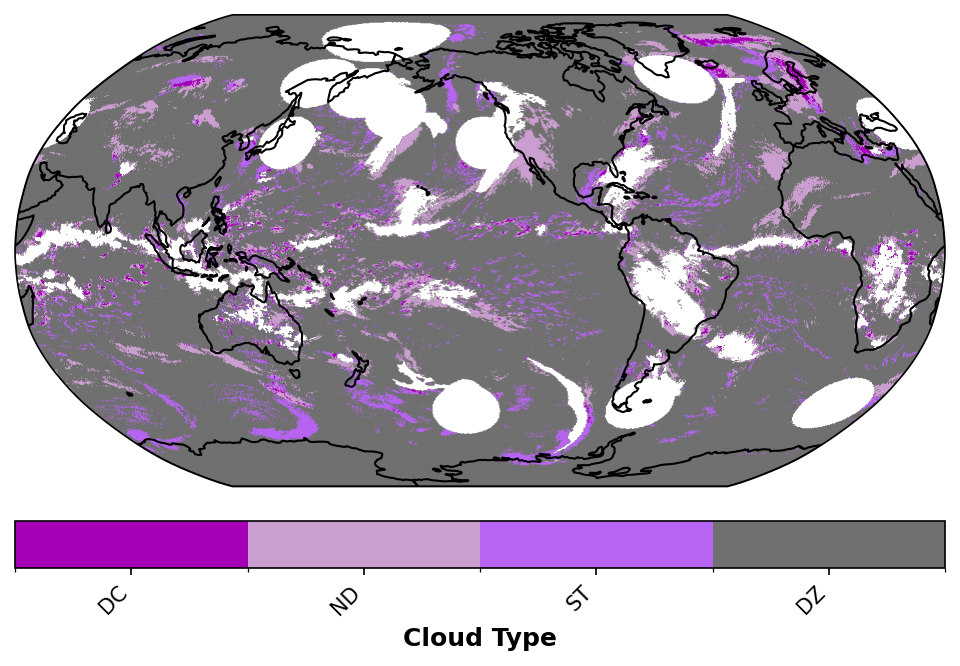

In [12]:
proj = ccrs.Robinson(central_longitude=225)
fig, ax = plt.subplots(figsize=(8,6), dpi=150, subplot_kw={'projection': proj})
ax.set_global()
ax.add_feature(cf.NaturalEarthFeature('physical', 'land', '110m'), 
                facecolor='none', edgecolor='k', zorder=3)
ax.set_aspect('auto', adjustable=None)

ctype_colors = [
    "#A500B7",  # 9: DC - dark purple
    "#CB9ED0",  # 10: ND - light purple/pink
    "#B664F1",  # 11: ST - light purple
    "#707070",  # 12: DZ - gray
]
cmap = ListedColormap(ctype_colors)
ctype_norm = BoundaryNorm(boundaries=np.arange(0.5, 5.5, 1), ncolors=4)
im = egh.healpix_show(cloud_types_cleaned.where(cloud_types_cleaned > 0), norm=ctype_norm, cmap=cmap, ax=ax)
cbar = plt.colorbar(im, orientation='horizontal', pad=0.05, ticks=np.arange(1,5), label='Cloud Types (Cleaned)')
cbar.set_label(f'Cloud Type', fontsize=12, fontweight='bold')
cbar.ax.set_xticklabels(['DC', 'ND', 'ST', 'DZ'], rotation=45, ha='right')

## Function to Count Extreme Precipitation by Storm Type

This function assigns cells exceeding a precipitation threshold to specific storm types

In [13]:
def count_extreme_precip_by_stormtype_spatial(pr, pr_threshold, ds_masks, cloud_types_cleaned=None):
    """
    Count cells where precipitation exceeds a threshold and assign to storm types.
    Returns SPATIAL arrays (per-cell counts) for mapping.
    
    This function identifies which storm type is responsible for extreme precipitation
    at each HEALPix cell for a single time step (6-hourly).
    
    Parameters:
    -----------
    pr : xr.DataArray
        Precipitation data for a single time step (cell dimension only)
        Shape: (cell,) with values in mm/h
    pr_threshold : float or xr.DataArray
        Precipitation threshold value (e.g., from pr_p90, pr_p95)
        Can be a scalar or DataArray with shape (cell,)
    ds_masks : xr.Dataset
        Dataset containing storm mask variables for the same time step
        Must include: mcs_isolated_mask, ar_isolated_mask, etc_isolated_mask, tc_mask
        and overlap masks for co-occurrence types
    cloud_types_cleaned : xr.DataArray, optional
        Cloud type mask (1=DC, 2=ND, 3=ST, 4=DZ) with tracked storms removed
        If None, cloud types will not be processed
    
    Returns:
    --------
    dict : Dictionary with storm type names as keys and spatial arrays (cell,) as values
        Each value is a binary mask (0 or 1) indicating whether that cell experienced
        extreme precipitation from that storm type.
        Keys include all storm types plus 'extreme_mask' for total extreme precip cells.
    
    Example:
    --------
    >>> pr_single = pr.sel(time='2020-01-01T00:00:00')
    >>> ds_single = ds.sel(time='2020-01-01T00:00:00')
    >>> threshold = dsx['pr_p90'].values
    >>> 
    >>> spatial_masks = count_extreme_precip_by_stormtype_spatial(
    ...     pr_single, threshold, ds_single, cloud_types_cleaned
    ... )
    >>> # spatial_masks['mcs_isolated'] is a DataArray with shape (cell,)
    """
    # Identify cells exceeding threshold
    extreme_mask = pr > pr_threshold
    
    # Initialize results dictionary with spatial arrays
    results = {
        'extreme_mask': extreme_mask.astype(float),
    }
    
    # Track which cells have been assigned (to avoid double counting)
    assigned_mask = xr.zeros_like(extreme_mask, dtype=bool)
    
    # Priority order: 3-way overlap > 2-way overlap > isolated storms > TC > cloud types
    
    # 1. Three-way co-occurrence: MCS+AR+ETC
    if 'mcs_ar_etc_3way_mask' in ds_masks:
        mask_3way = ds_masks['mcs_ar_etc_3way_mask'] > 0
    else:
        mask_3way = create_union_mask([
            ds_masks['mcs_ar_etc_overlap_mask'],
            ds_masks['ar_mcs_etc_overlap_mask'],
            ds_masks['etc_mcs_ar_overlap_mask'],
        ]) > 0
    
    extreme_3way = (extreme_mask & mask_3way & ~assigned_mask).astype(float)
    results['mcs_ar_etc_3way'] = extreme_3way
    assigned_mask = assigned_mask | (extreme_3way > 0)
    
    # 2. Two-way co-occurrences
    # MCS+AR
    if 'mcs_ar_2way_mask' in ds_masks:
        mask_mcs_ar = ds_masks['mcs_ar_2way_mask'] > 0
    else:
        mask_mcs_ar = create_union_mask([
            ds_masks['mcs_ar_overlap_mask'],
            ds_masks['ar_mcs_overlap_mask'],
        ]) > 0
    
    extreme_mcs_ar = (extreme_mask & mask_mcs_ar & ~assigned_mask).astype(float)
    results['mcs_ar_2way'] = extreme_mcs_ar
    assigned_mask = assigned_mask | (extreme_mcs_ar > 0)
    
    # MCS+ETC
    if 'mcs_etc_2way_mask' in ds_masks:
        mask_mcs_etc = ds_masks['mcs_etc_2way_mask'] > 0
    else:
        mask_mcs_etc = create_union_mask([
            ds_masks['mcs_etc_overlap_mask'],
            ds_masks['etc_mcs_overlap_mask'],
        ]) > 0
    
    extreme_mcs_etc = (extreme_mask & mask_mcs_etc & ~assigned_mask).astype(float)
    results['mcs_etc_2way'] = extreme_mcs_etc
    assigned_mask = assigned_mask | (extreme_mcs_etc > 0)
    
    # AR+ETC
    if 'ar_etc_2way_mask' in ds_masks:
        mask_ar_etc = ds_masks['ar_etc_2way_mask'] > 0
    else:
        mask_ar_etc = create_union_mask([
            ds_masks['ar_etc_overlap_mask'],
            ds_masks['etc_ar_overlap_mask'],
        ]) > 0
    
    extreme_ar_etc = (extreme_mask & mask_ar_etc & ~assigned_mask).astype(float)
    results['ar_etc_2way'] = extreme_ar_etc
    assigned_mask = assigned_mask | (extreme_ar_etc > 0)
    
    # 3. Isolated storms
    # MCS isolated
    mask_mcs_iso = ds_masks['mcs_isolated_mask'] > 0
    extreme_mcs_iso = (extreme_mask & mask_mcs_iso & ~assigned_mask).astype(float)
    results['mcs_isolated'] = extreme_mcs_iso
    assigned_mask = assigned_mask | (extreme_mcs_iso > 0)
    
    # AR isolated
    mask_ar_iso = ds_masks['ar_isolated_mask'] > 0
    extreme_ar_iso = (extreme_mask & mask_ar_iso & ~assigned_mask).astype(float)
    results['ar_isolated'] = extreme_ar_iso
    assigned_mask = assigned_mask | (extreme_ar_iso > 0)
    
    # ETC isolated
    mask_etc_iso = ds_masks['etc_isolated_mask'] > 0
    extreme_etc_iso = (extreme_mask & mask_etc_iso & ~assigned_mask).astype(float)
    results['etc_isolated'] = extreme_etc_iso
    assigned_mask = assigned_mask | (extreme_etc_iso > 0)
    
    # 4. TC (tropical cyclones)
    mask_tc = ds_masks['tc_mask'] > 0
    extreme_tc = (extreme_mask & mask_tc & ~assigned_mask).astype(float)
    results['tc'] = extreme_tc
    assigned_mask = assigned_mask | (extreme_tc > 0)
    
    # 5. Cloud types (non-tracked precipitation)
    if cloud_types_cleaned is not None:
        # Deep convection (DC = 1)
        mask_dc = (cloud_types_cleaned == 1)
        extreme_dc = (extreme_mask & mask_dc & ~assigned_mask).astype(float)
        results['dc'] = extreme_dc
        assigned_mask = assigned_mask | (extreme_dc > 0)
        
        # Non-deep convection (ND = 2)
        mask_nd = (cloud_types_cleaned == 2)
        extreme_nd = (extreme_mask & mask_nd & ~assigned_mask).astype(float)
        results['nd'] = extreme_nd
        assigned_mask = assigned_mask | (extreme_nd > 0)
        
        # Stratiform (ST = 3)
        mask_st = (cloud_types_cleaned == 3)
        extreme_st = (extreme_mask & mask_st & ~assigned_mask).astype(float)
        results['st'] = extreme_st
        assigned_mask = assigned_mask | (extreme_st > 0)
        
        # Drizzle (DZ = 4)
        mask_dz = (cloud_types_cleaned == 4)
        extreme_dz = (extreme_mask & mask_dz & ~assigned_mask).astype(float)
        results['dz'] = extreme_dz
        assigned_mask = assigned_mask | (extreme_dz > 0)
    else:
        # Initialize with zeros if cloud types not provided
        results['dc'] = xr.zeros_like(extreme_mask, dtype=float)
        results['nd'] = xr.zeros_like(extreme_mask, dtype=float)
        results['st'] = xr.zeros_like(extreme_mask, dtype=float)
        results['dz'] = xr.zeros_like(extreme_mask, dtype=float)
    
    # Unassigned cells
    results['unassigned'] = (extreme_mask & ~assigned_mask).astype(float)
    
    return results

print("✅ count_extreme_precip_by_stormtype_spatial() function defined")

✅ count_extreme_precip_by_stormtype_spatial() function defined


### Test the function with a single time step

In [14]:
# Select a single time step for testing
test_time = '2020-01-01T00:00:00'
pr_single = pr.sel(time=test_time)
ds_single = ds.sel(time=test_time)

# Get the 90th percentile threshold
pr_p90_threshold = dsx['pr_p90'].values

# Prepare the 2-way and 3-way masks for this time step
ds_single['mcs_ar_2way_mask'] = create_union_mask([
    ds_single['mcs_ar_overlap_mask'],
    ds_single['ar_mcs_overlap_mask'],
])
ds_single['mcs_etc_2way_mask'] = create_union_mask([
    ds_single['mcs_etc_overlap_mask'],
    ds_single['etc_mcs_overlap_mask'],
])
ds_single['ar_etc_2way_mask'] = create_union_mask([
    ds_single['ar_etc_overlap_mask'],
    ds_single['etc_ar_overlap_mask'],
])
ds_single['mcs_ar_etc_3way_mask'] = create_union_mask([
    ds_single['mcs_ar_etc_overlap_mask'],
    ds_single['ar_mcs_etc_overlap_mask'],
    ds_single['etc_mcs_ar_overlap_mask'],
])

# Create cleaned cloud types (excluding all tracked storms)
cloud_types_single = ds_single['cloud_types']
cloud_types_cleaned_single = xr.where(
    ((ds_single['mcs_isolated_mask'] > 0) |
     (ds_single['ar_isolated_mask'] > 0) |
     (ds_single['etc_isolated_mask'] > 0) |
     (ds_single['tc_mask'] > 0) |
     (ds_single['mcs_ar_2way_mask'] > 0) |
     (ds_single['mcs_etc_2way_mask'] > 0) |
     (ds_single['ar_etc_2way_mask'] > 0) |
     (ds_single['mcs_ar_etc_3way_mask'] > 0)), 
    0, cloud_types_single, keep_attrs=True
)

# Run the counting function
counts = count_extreme_precip_by_stormtype_spatial(
    pr_single, pr_p90_threshold, ds_single, cloud_types_cleaned_single
)

# # Display results
# print(f"Extreme Precipitation Attribution (P90 threshold)")
# print("=" * 60)
# print(f"\nTotal cells exceeding threshold: {counts['total_extreme']:,}")
# print(f"\nIsolated Storms:")
# print(f"  MCS isolated:     {counts['mcs_isolated']:>8,} ({100*counts['mcs_isolated']/max(counts['total_extreme'],1):.1f}%)")
# print(f"  AR isolated:      {counts['ar_isolated']:>8,} ({100*counts['ar_isolated']/max(counts['total_extreme'],1):.1f}%)")
# print(f"  ETC isolated:     {counts['etc_isolated']:>8,} ({100*counts['etc_isolated']/max(counts['total_extreme'],1):.1f}%)")
# print(f"  TC:               {counts['tc']:>8,} ({100*counts['tc']/max(counts['total_extreme'],1):.1f}%)")

# print(f"\nCo-occurring Storms (2-way):")
# print(f"  MCS+AR:           {counts['mcs_ar_2way']:>8,} ({100*counts['mcs_ar_2way']/max(counts['total_extreme'],1):.1f}%)")
# print(f"  MCS+ETC:          {counts['mcs_etc_2way']:>8,} ({100*counts['mcs_etc_2way']/max(counts['total_extreme'],1):.1f}%)")
# print(f"  AR+ETC:           {counts['ar_etc_2way']:>8,} ({100*counts['ar_etc_2way']/max(counts['total_extreme'],1):.1f}%)")

# print(f"\nCo-occurring Storms (3-way):")
# print(f"  MCS+AR+ETC:       {counts['mcs_ar_etc_3way']:>8,} ({100*counts['mcs_ar_etc_3way']/max(counts['total_extreme'],1):.1f}%)")

# print(f"\nNon-tracked Cloud Types:")
# print(f"  Deep convection:  {counts['dc']:>8,} ({100*counts['dc']/max(counts['total_extreme'],1):.1f}%)")
# print(f"  Non-deep conv:    {counts['nd']:>8,} ({100*counts['nd']/max(counts['total_extreme'],1):.1f}%)")
# print(f"  Stratiform:       {counts['st']:>8,} ({100*counts['st']/max(counts['total_extreme'],1):.1f}%)")
# print(f"  Drizzle:          {counts['dz']:>8,} ({100*counts['dz']/max(counts['total_extreme'],1):.1f}%)")

# print(f"\nUnassigned:         {counts['unassigned']:>8,} ({100*counts['unassigned']/max(counts['total_extreme'],1):.1f}%)")
# print("=" * 60)

In [15]:
counts['mcs_ar_etc_3way']

<xarray.DataArray (cell: 786432)> Size: 6MB
dask.array<astype, shape=(786432,), dtype=float64, chunksize=(786432,), chunktype=numpy.ndarray>
Coordinates:
    lat      (cell) float64 6MB 0.1492 0.2984 0.2984 ... -0.2984 -0.2984 -0.1492
    lon      (cell) float64 6MB 45.0 45.18 44.82 45.0 ... 315.2 314.8 315.0
    time     datetime64[ns] 8B 2020-01-01
    crs      int64 8B 0
  * cell     (cell) int64 6MB 0 1 2 3 4 5 ... 786427 786428 786429 786430 786431

<Figure size 640x480 with 0 Axes>

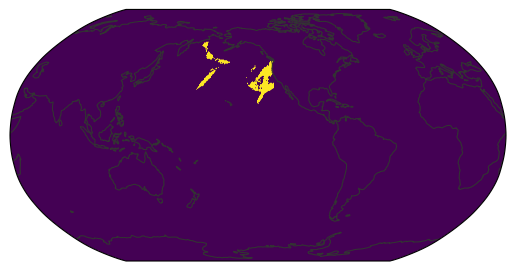

In [16]:
egh.healpix_show(counts['mcs_ar_etc_3way'])

## Function for Time Series Processing and Aggregation

Process all time steps and aggregate results for ranking storm type contributions

In [ ]:
def process_timeseries_extreme_precip_spatial(pr, pr_threshold, ds, percentile_name='P90', 
                                                compute_cloud_types=True, time_chunk_size=100):
    """
    Process all time steps and accumulate spatial counts by storm type.
    Returns per-cell counts for mapping dominant storm types.
    
    Parameters:
    -----------
    pr : xr.DataArray
        Precipitation data with time and cell dimensions (mm/h)
    pr_threshold : float or xr.DataArray
        Precipitation threshold (e.g., from pr_p90)
    ds : xr.Dataset
        Dataset containing storm mask variables for all time steps
    percentile_name : str
        Name for the percentile (for reporting, e.g., 'P90', 'P95')
    compute_cloud_types : bool
        Whether to compute cloud type contributions
    time_chunk_size : int
        Number of time steps to process at once (for memory management)
    
    Returns:
    --------
    xr.Dataset : Dataset with spatial counts for each storm type
        Variables include counts for each storm type with shape (cell,)
        Also includes 'dominant_type' - the storm type with highest count at each cell
        and 'dominant_type_name' - descriptive name of dominant type
    
    Example:
    --------
    >>> pr_p90 = dsx['pr_p90'].values
    >>> ds_spatial = process_timeseries_extreme_precip_spatial(pr, pr_p90, ds, 'P90')
    >>> # Plot dominant storm type
    >>> egh.healpix_show(ds_spatial['dominant_type'])
    """
    from tqdm import tqdm
    
    # Initialize spatial accumulators (per-cell counts)
    ncells = len(pr.cell)
    accumulated_spatial = {
        'total_extreme': xr.zeros_like(pr.isel(time=0)),
        'mcs_isolated': xr.zeros_like(pr.isel(time=0)),
        'ar_isolated': xr.zeros_like(pr.isel(time=0)),
        'etc_isolated': xr.zeros_like(pr.isel(time=0)),
        'tc': xr.zeros_like(pr.isel(time=0)),
        'mcs_ar_2way': xr.zeros_like(pr.isel(time=0)),
        'mcs_etc_2way': xr.zeros_like(pr.isel(time=0)),
        'ar_etc_2way': xr.zeros_like(pr.isel(time=0)),
        'mcs_ar_etc_3way': xr.zeros_like(pr.isel(time=0)),
        'dc': xr.zeros_like(pr.isel(time=0)),
        'nd': xr.zeros_like(pr.isel(time=0)),
        'st': xr.zeros_like(pr.isel(time=0)),
        'dz': xr.zeros_like(pr.isel(time=0)),
        'unassigned': xr.zeros_like(pr.isel(time=0)),
    }
    
    ntimes = len(pr.time)
    print(f"Processing {ntimes} time steps for {percentile_name} threshold (spatial)...")
    
    # Process in chunks to manage memory
    for i in tqdm(range(0, ntimes, time_chunk_size)):
        end_idx = min(i + time_chunk_size, ntimes)
        time_slice = slice(i, end_idx)
        
        # Get chunk of data
        pr_chunk = pr.isel(time=time_slice)
        ds_chunk = ds.isel(time=time_slice)
        
        # Process each time step in the chunk
        for t in range(len(pr_chunk.time)):
            pr_t = pr_chunk.isel(time=t)
            ds_t = ds_chunk.isel(time=t)
            
            # Create union masks for this time step
            ds_t['mcs_ar_2way_mask'] = create_union_mask([
                ds_t['mcs_ar_overlap_mask'],
                ds_t['ar_mcs_overlap_mask'],
            ])
            ds_t['mcs_etc_2way_mask'] = create_union_mask([
                ds_t['mcs_etc_overlap_mask'],
                ds_t['etc_mcs_overlap_mask'],
            ])
            ds_t['ar_etc_2way_mask'] = create_union_mask([
                ds_t['ar_etc_overlap_mask'],
                ds_t['etc_ar_overlap_mask'],
            ])
            ds_t['mcs_ar_etc_3way_mask'] = create_union_mask([
                ds_t['mcs_ar_etc_overlap_mask'],
                ds_t['ar_mcs_etc_overlap_mask'],
                ds_t['etc_mcs_ar_overlap_mask'],
            ])
            
            # Prepare cloud types if requested
            cloud_types_cleaned_t = None
            if compute_cloud_types and 'cloud_types' in ds_t:
                cloud_types_t = ds_t['cloud_types']
                cloud_types_cleaned_t = xr.where(
                    ((ds_t['mcs_isolated_mask'] > 0) |
                     (ds_t['ar_isolated_mask'] > 0) |
                     (ds_t['etc_isolated_mask'] > 0) |
                     (ds_t['tc_mask'] > 0) |
                     (ds_t['mcs_ar_2way_mask'] > 0) |
                     (ds_t['mcs_etc_2way_mask'] > 0) |
                     (ds_t['ar_etc_2way_mask'] > 0) |
                     (ds_t['mcs_ar_etc_3way_mask'] > 0)), 
                    0, cloud_types_t, keep_attrs=True
                )
            
            # Get spatial masks for this time step
            spatial_masks = count_extreme_precip_by_stormtype_spatial(
                pr_t, pr_threshold, ds_t, cloud_types_cleaned_t
            )
            
            # Accumulate spatial counts
            accumulated_spatial['total_extreme'] += spatial_masks['extreme_mask']
            for key in ['mcs_isolated', 'ar_isolated', 'etc_isolated', 'tc',
                       'mcs_ar_2way', 'mcs_etc_2way', 'ar_etc_2way', 'mcs_ar_etc_3way',
                       'dc', 'nd', 'st', 'dz', 'unassigned']:
                accumulated_spatial[key] += spatial_masks[key]
    
    # Create output dataset with spatial counts
    storm_type_order = [
        'mcs_isolated', 'ar_isolated', 'etc_isolated', 'tc',
        'mcs_ar_2way', 'mcs_etc_2way', 'ar_etc_2way', 'mcs_ar_etc_3way',
        'dc', 'nd', 'st', 'dz', 'unassigned'
    ]
    storm_type_names = [
        'MCS (isolated)', 'AR (isolated)', 'ETC (isolated)', 'TC',
        'MCS+AR', 'MCS+ETC', 'AR+ETC', 'MCS+AR+ETC',
        'Deep Convection', 'Non-deep Convection', 'Stratiform', 'Drizzle',
        'Unassigned'
    ]
    
    # Stack all storm type counts into a 2D array (storm_type, cell)
    count_stack = np.stack([accumulated_spatial[key].values for key in storm_type_order], axis=0)
    
    # Find dominant storm type at each cell (argmax along storm_type dimension)
    dominant_idx = np.argmax(count_stack, axis=0)
    
    # Create dominant type categorical variable (1-13, 0 for no extreme precip)
    dominant_type = xr.DataArray(
        dominant_idx + 1,  # 1-based indexing
        dims=['cell'],
        coords={'cell': accumulated_spatial['total_extreme'].cell},
        name='dominant_type'
    )
    # Set to 0 where there's no extreme precipitation
    dominant_type = dominant_type.where(accumulated_spatial['total_extreme'] > 0, 0)
    
    # Create dataset
    ds_out = xr.Dataset(coords={'cell': accumulated_spatial['total_extreme'].cell})
    
    # Add total extreme count
    ds_out['total_extreme'] = accumulated_spatial['total_extreme']
    ds_out['total_extreme'].attrs = {
        'long_name': 'Total count of extreme precipitation occurrences',
        'units': 'count',
        'percentile': percentile_name
    }
    
    # Add counts for each storm type
    for i, (key, name) in enumerate(zip(storm_type_order, storm_type_names)):
        ds_out[f'{key}_count'] = accumulated_spatial[key]
        ds_out[f'{key}_count'].attrs = {
            'long_name': f'Count of extreme precip from {name}',
            'units': 'count',
            'storm_type_code': i + 1
        }
    
    # Add dominant storm type
    ds_out['dominant_type'] = dominant_type
    ds_out['dominant_type'].attrs = {
        'long_name': 'Dominant storm type for extreme precipitation',
        'units': 'category',
        'description': 'Storm type with highest count of extreme precip at each cell',
        'categories': ', '.join([f'{i+1}: {name}' for i, name in enumerate(storm_type_names)]),
        '0': 'No extreme precipitation'
    }
    
    # Add lat/lon if available
    if 'lat' in pr.coords:
        ds_out['lat'] = pr.lat
        ds_out['lon'] = pr.lon
    
    # Global attributes
    ds_out.attrs = {
        'title': f'Spatial distribution of extreme precipitation by storm type ({percentile_name})',
        'percentile': percentile_name,
        'description': 'Per-cell counts of extreme precipitation occurrences by storm type',
        'ntimes_processed': ntimes,
    }
    
    return ds_out

print("✅ process_timeseries_extreme_precip_spatial() function defined")

✅ process_timeseries_extreme_precip_spatial() function defined


In [18]:
def analyze_and_rank_stormtypes(accumulated_counts, top_n=3):
    """
    Analyze accumulated counts and rank storm types by contribution.
    
    Parameters:
    -----------
    accumulated_counts : dict
        Dictionary from process_timeseries_extreme_precip()
    top_n : int
        Number of top contributors to report
    
    Returns:
    --------
    pandas.DataFrame : DataFrame with storm type rankings and statistics
    
    Example:
    --------
    >>> results = process_timeseries_extreme_precip(pr, pr_p90, ds, 'P90')
    >>> df = analyze_and_rank_stormtypes(results, top_n=3)
    >>> print(df)
    """
    import pandas as pd
    
    # Define storm type categories
    storm_types = {
        'MCS (isolated)': 'mcs_isolated',
        'AR (isolated)': 'ar_isolated',
        'ETC (isolated)': 'etc_isolated',
        'TC': 'tc',
        'MCS+AR': 'mcs_ar_2way',
        'MCS+ETC': 'mcs_etc_2way',
        'AR+ETC': 'ar_etc_2way',
        'MCS+AR+ETC': 'mcs_ar_etc_3way',
        'Deep Convection': 'dc',
        'Non-deep Convection': 'nd',
        'Stratiform': 'st',
        'Drizzle': 'dz',
    }
    
    total = accumulated_counts['total_extreme']
    
    # Create results list
    results = []
    for name, key in storm_types.items():
        count = accumulated_counts[key]
        percentage = 100 * count / total if total > 0 else 0
        results.append({
            'Storm Type': name,
            'Count': count,
            'Percentage': percentage,
        })
    
    # Add unassigned
    results.append({
        'Storm Type': 'Unassigned',
        'Count': accumulated_counts['unassigned'],
        'Percentage': 100 * accumulated_counts['unassigned'] / total if total > 0 else 0,
    })
    
    # Create DataFrame and sort by count
    df = pd.DataFrame(results)
    df = df.sort_values('Count', ascending=False).reset_index(drop=True)
    df['Rank'] = range(1, len(df) + 1)
    
    # Reorder columns
    df = df[['Rank', 'Storm Type', 'Count', 'Percentage']]
    
    return df

print("✅ analyze_and_rank_stormtypes() function defined")

✅ analyze_and_rank_stormtypes() function defined


### Test with a subset of time series (for demonstration)

Process a few months to demonstrate the workflow

In [30]:
# Test with a subset of data (e.g., January 2020)
pr_subset = pr.sel(time=slice('2020-01-01', '2020-01-31'))
ds_subset = ds.sel(time=slice('2020-01-01', '2020-01-31'))

print(f"Processing {len(pr_subset.time)} time steps...")

# Process for P90 threshold
pr_p90 = dsx['pr_p90'].values
results_p90 = process_timeseries_extreme_precip_spatial(
    pr_subset, pr_p90, ds_subset, 
    percentile_name='P90',
    compute_cloud_types=True,
    time_chunk_size=50
)

# # Analyze and rank
# df_p90 = analyze_and_rank_stormtypes(results_p90, top_n=3)

# print("\n" + "=" * 80)
# print(f"P90 Extreme Precipitation Attribution (January 2020)")
# print("=" * 80)
# print(f"\nTotal extreme precipitation occurrences: {results_p90['total_extreme']:,}")
# print(f"\nTop 10 Storm Types Contributing to Extreme Precipitation:")
# print(df_p90.head(10).to_string(index=False))
# print("\n" + "=" * 80)

Processing 124 time steps...
Processing 124 time steps for P90 threshold (spatial)...
Processing 124 time steps for P90 threshold (spatial)...


  0%|          | 0/3 [00:00<?, ?it/s]

100%|██████████| 3/3 [00:30<00:00, 10.23s/it]



In [31]:
results_p90

<xarray.Dataset> Size: 113MB
Dimensions:                (cell: 786432)
Coordinates:
    lat                    (cell) float64 6MB 0.1492 0.2984 ... -0.2984 -0.1492
    lon                    (cell) float64 6MB 45.0 45.18 44.82 ... 314.8 315.0
    time                   datetime64[ns] 8B 2020-01-01
    crs                    int64 8B 0
  * cell                   (cell) int64 6MB 0 1 2 3 ... 786429 786430 786431
Data variables: (12/15)
    total_extreme          (cell) float64 6MB dask.array<chunksize=(786432,), meta=np.ndarray>
    mcs_isolated_count     (cell) float64 6MB dask.array<chunksize=(786432,), meta=np.ndarray>
    ar_isolated_count      (cell) float64 6MB dask.array<chunksize=(786432,), meta=np.ndarray>
    etc_isolated_count     (cell) float64 6MB dask.array<chunksize=(786432,), meta=np.ndarray>
    tc_count               (cell) float64 6MB dask.array<chunksize=(786432,), meta=np.ndarray>
    mcs_ar_2way_count      (cell) float64 6MB dask.array<chunksize=(786432,), meta=np.ndarray>
    ...                     ...
    dc_count               (cell) float64 6MB dask.array<chunksize=(786432,), meta=np.ndarray>
    nd_count               (cell) float64 6MB dask.array<chunksize=(786432,), meta=np.ndarray>
    st_count               (cell) float64 6MB dask.array<chunksize=(786432,), meta=np.ndarray>
    dz_count               (cell) float64 6MB dask.array<chunksize=(786432,), meta=np.ndarray>
    unassigned_count       (cell) float64 6MB dask.array<chunksize=(786432,), meta=np.ndarray>
    dominant_type          (cell) int64 6MB dask.array<chunksize=(786432,), meta=np.ndarray>
Attributes:
    title:             Spatial distribution of extreme precipitation by storm...
    percentile:        P90
    description:       Per-cell counts of extreme precipitation occurrences b...
    ntimes_processed:  124

### Test Spatial Processing (Retains Cell-Level Counts)

In [32]:
# Process spatial counts for January 2020 subset
pr_p90 = dsx['pr_p90'].values

ds_spatial_p90 = process_timeseries_extreme_precip_spatial(
    pr_subset, pr_p90, ds_subset,
    percentile_name='P90',
    compute_cloud_types=True,
    time_chunk_size=50
)

print("\n" + "=" * 80)
print("Spatial Processing Complete!")
print("=" * 80)
print(f"\nDataset contains per-cell counts for {len(ds_spatial_p90.data_vars)} variables")
print(f"Total cells with extreme precipitation: {int((ds_spatial_p90['total_extreme'] > 0).sum().values):,}")
print(f"Mean extreme precip count per cell: {float(ds_spatial_p90['total_extreme'].mean().values):.2f}")
print("\n" + "=" * 80)

ds_spatial_p90

Processing 124 time steps for P90 threshold (spatial)...


100%|██████████| 3/3 [00:33<00:00, 11.01s/it]




Spatial Processing Complete!

Dataset contains per-cell counts for 15 variables
Total cells with extreme precipitation: 659,469
Total cells with extreme precipitation: 659,469
Mean extreme precip count per cell: 12.52

Mean extreme precip count per cell: 12.52



<xarray.Dataset> Size: 113MB
Dimensions:                (cell: 786432)
Coordinates:
    lat                    (cell) float64 6MB 0.1492 0.2984 ... -0.2984 -0.1492
    lon                    (cell) float64 6MB 45.0 45.18 44.82 ... 314.8 315.0
    time                   datetime64[ns] 8B 2020-01-01
    crs                    int64 8B 0
  * cell                   (cell) int64 6MB 0 1 2 3 ... 786429 786430 786431
Data variables: (12/15)
    total_extreme          (cell) float64 6MB dask.array<chunksize=(786432,), meta=np.ndarray>
    mcs_isolated_count     (cell) float64 6MB dask.array<chunksize=(786432,), meta=np.ndarray>
    ar_isolated_count      (cell) float64 6MB dask.array<chunksize=(786432,), meta=np.ndarray>
    etc_isolated_count     (cell) float64 6MB dask.array<chunksize=(786432,), meta=np.ndarray>
    tc_count               (cell) float64 6MB dask.array<chunksize=(786432,), meta=np.ndarray>
    mcs_ar_2way_count      (cell) float64 6MB dask.array<chunksize=(786432,), meta=np.ndarray>
    ...                     ...
    dc_count               (cell) float64 6MB dask.array<chunksize=(786432,), meta=np.ndarray>
    nd_count               (cell) float64 6MB dask.array<chunksize=(786432,), meta=np.ndarray>
    st_count               (cell) float64 6MB dask.array<chunksize=(786432,), meta=np.ndarray>
    dz_count               (cell) float64 6MB dask.array<chunksize=(786432,), meta=np.ndarray>
    unassigned_count       (cell) float64 6MB dask.array<chunksize=(786432,), meta=np.ndarray>
    dominant_type          (cell) int64 6MB dask.array<chunksize=(786432,), meta=np.ndarray>
Attributes:
    title:             Spatial distribution of extreme precipitation by storm...
    percentile:        P90
    description:       Per-cell counts of extreme precipitation occurrences b...
    ntimes_processed:  124

In [33]:
ds_spatial_p90['total_extreme'].max().values.astype(int).item()

89

### Visualize Spatial Distribution

Plot maps showing dominant storm types and their counts

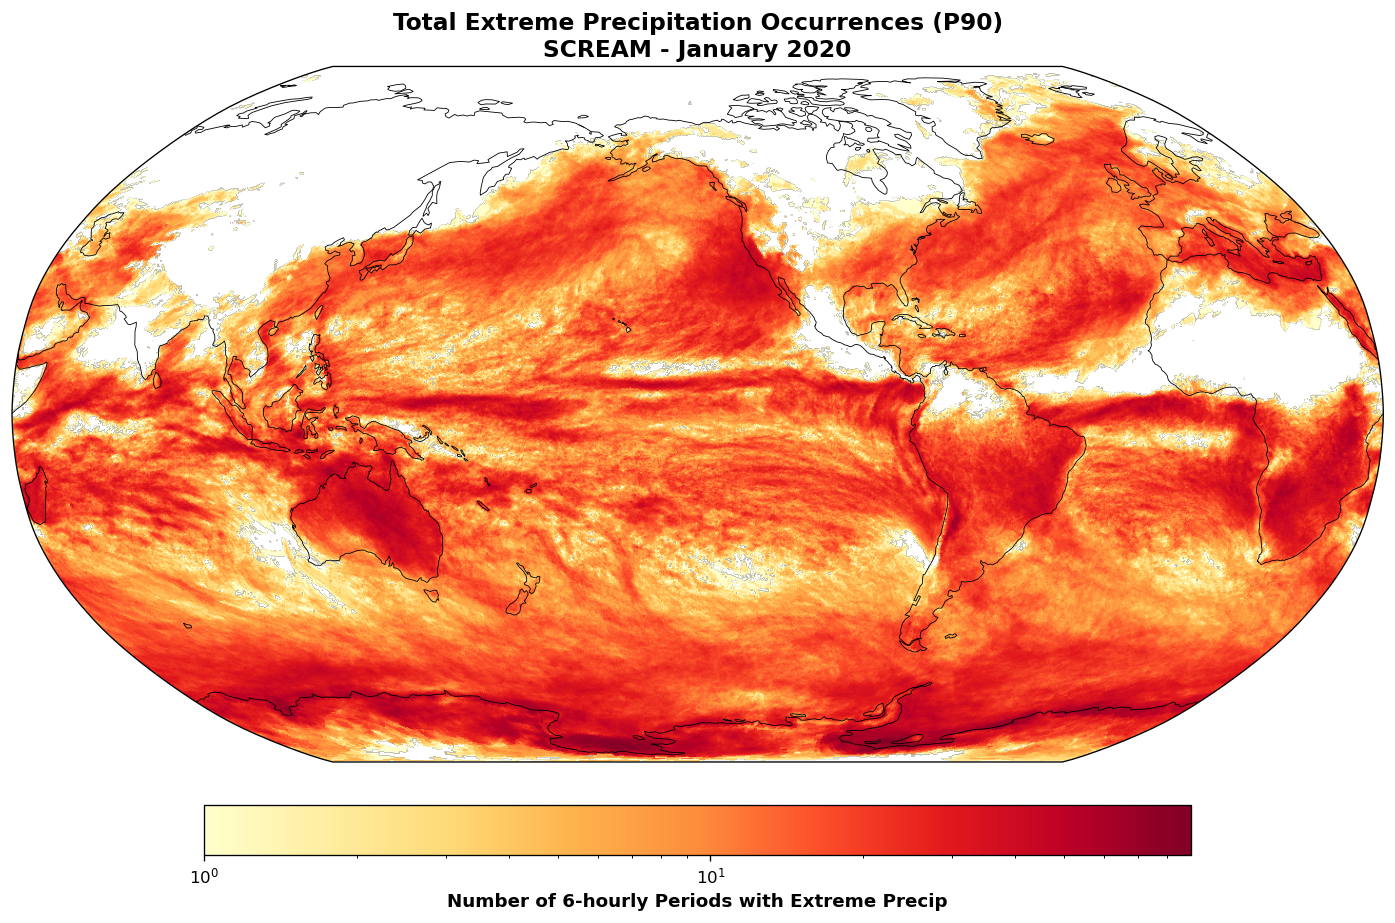

In [34]:
# Map 1: Total extreme precipitation count
proj = ccrs.Robinson(central_longitude=-137)
fig, ax = plt.subplots(figsize=(14, 8), dpi=120, subplot_kw={'projection': proj})
ax.set_global()
ax.add_feature(cf.COASTLINE, linewidth=0.5)
ax.set_title(f'Total Extreme Precipitation Occurrences (P90)\n{source_name.upper()} - January 2020', 
             fontsize=14, fontweight='bold')

# Plot total extreme count
im = egh.healpix_show(
    ds_spatial_p90['total_extreme'].where(ds_spatial_p90['total_extreme'] > 0),
    ax=ax, 
    cmap='YlOrRd',
    norm=mpl.colors.LogNorm(vmin=1, vmax=ds_spatial_p90['total_extreme'].max().values.astype(int).item())
)
cbar = plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.05, shrink=0.6)
cbar.set_label('Number of 6-hourly Periods with Extreme Precip', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

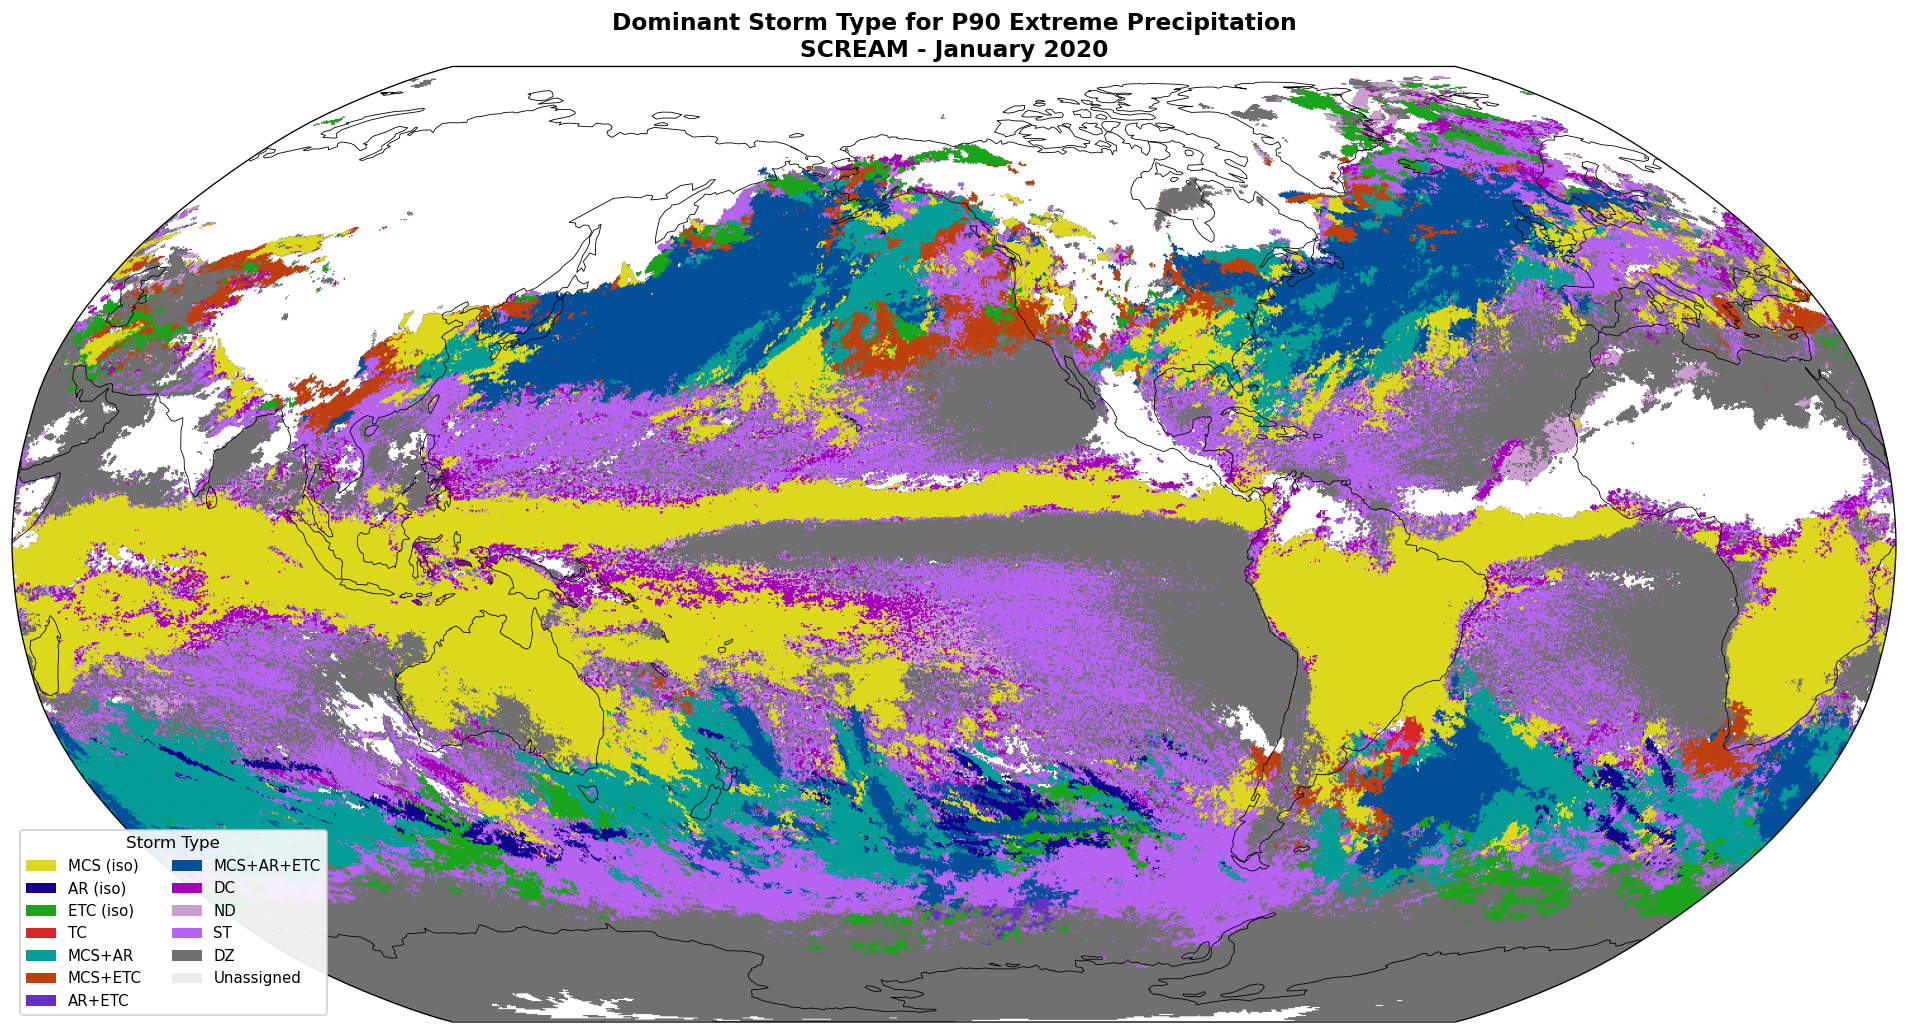

In [35]:
# Map 2: Dominant storm type
proj = ccrs.Robinson(central_longitude=-137)
fig, ax = plt.subplots(figsize=(16, 9), dpi=120, subplot_kw={'projection': proj})
ax.set_global()
ax.add_feature(cf.COASTLINE, linewidth=0.5)
ax.set_title(f'Dominant Storm Type for P90 Extreme Precipitation\n{source_name.upper()} - January 2020', 
             fontsize=14, fontweight='bold')

# Define colors for each storm type (13 categories)
storm_colors = [
    # '#1f77b4',  # 1: MCS (isolated) - blue
    # '#ff7f0e',  # 2: AR (isolated) - orange
    # '#2ca02c',  # 3: ETC (isolated) - green
    # '#d62728',  # 4: TC - red
    # '#9467bd',  # 5: MCS+AR - purple
    # '#8c564b',  # 6: MCS+ETC - brown
    # '#e377c2',  # 7: AR+ETC - pink
    # '#7f7f7f',  # 8: MCS+AR+ETC - gray
    # '#bcbd22',  # 9: DC - yellow-green
    # '#17becf',  # 10: ND - cyan
    # '#aec7e8',  # 11: ST - light blue
    # '#ffbb78',  # 12: DZ - light orange
    # '#c7c7c7',  # 13: Unassigned - light gray
    "#DCD91C",  # 1: MCS_iso - yellow
    "#11008d",  # 2: AR_iso - dark blue
    "#19a519",  # 3: ETC_iso - green
    '#d62728',  # 4: TC - red
    "#059D96",  # 5: MCS_AR - teal/cyan
    "#BF3F0D",  # 6: AR_ETC - brownish orange
    "#6332C4",  # 7: MCS_ETC - purple
    "#044F9A",  # 8: MCS_AR_ETC - dark blue
    "#A500B7",  # 9: DC - dark purple
    "#CB9ED0",  # 10: ND - light purple/pink
    "#B664F1",  # 11: ST - light purple
    "#707070",  # 12: DZ - gray
    "#DFDFDF9F",  # 13: Residual - light gray
]

cmap = ListedColormap(storm_colors)
norm = BoundaryNorm(boundaries=np.arange(0.5, 14.5, 1), ncolors=13)

# Plot dominant type (only where there's extreme precip)
dominant_plot = ds_spatial_p90['dominant_type'].where(ds_spatial_p90['dominant_type'] > 0)
im = egh.healpix_show(dominant_plot, ax=ax, cmap=cmap, norm=norm)

# Create custom legend
storm_labels = [
    'MCS (iso)', 'AR (iso)', 'ETC (iso)', 'TC',
    'MCS+AR', 'MCS+ETC', 'AR+ETC', 'MCS+AR+ETC',
    'DC', 'ND', 'ST', 'DZ', 'Unassigned'
]
legend_elements = [Patch(facecolor=storm_colors[i], label=storm_labels[i]) 
                   for i in range(13)]
ax.legend(handles=legend_elements, loc='lower left', ncol=2, 
          fontsize=9, framealpha=0.9, title='Storm Type')

plt.tight_layout()
plt.show()

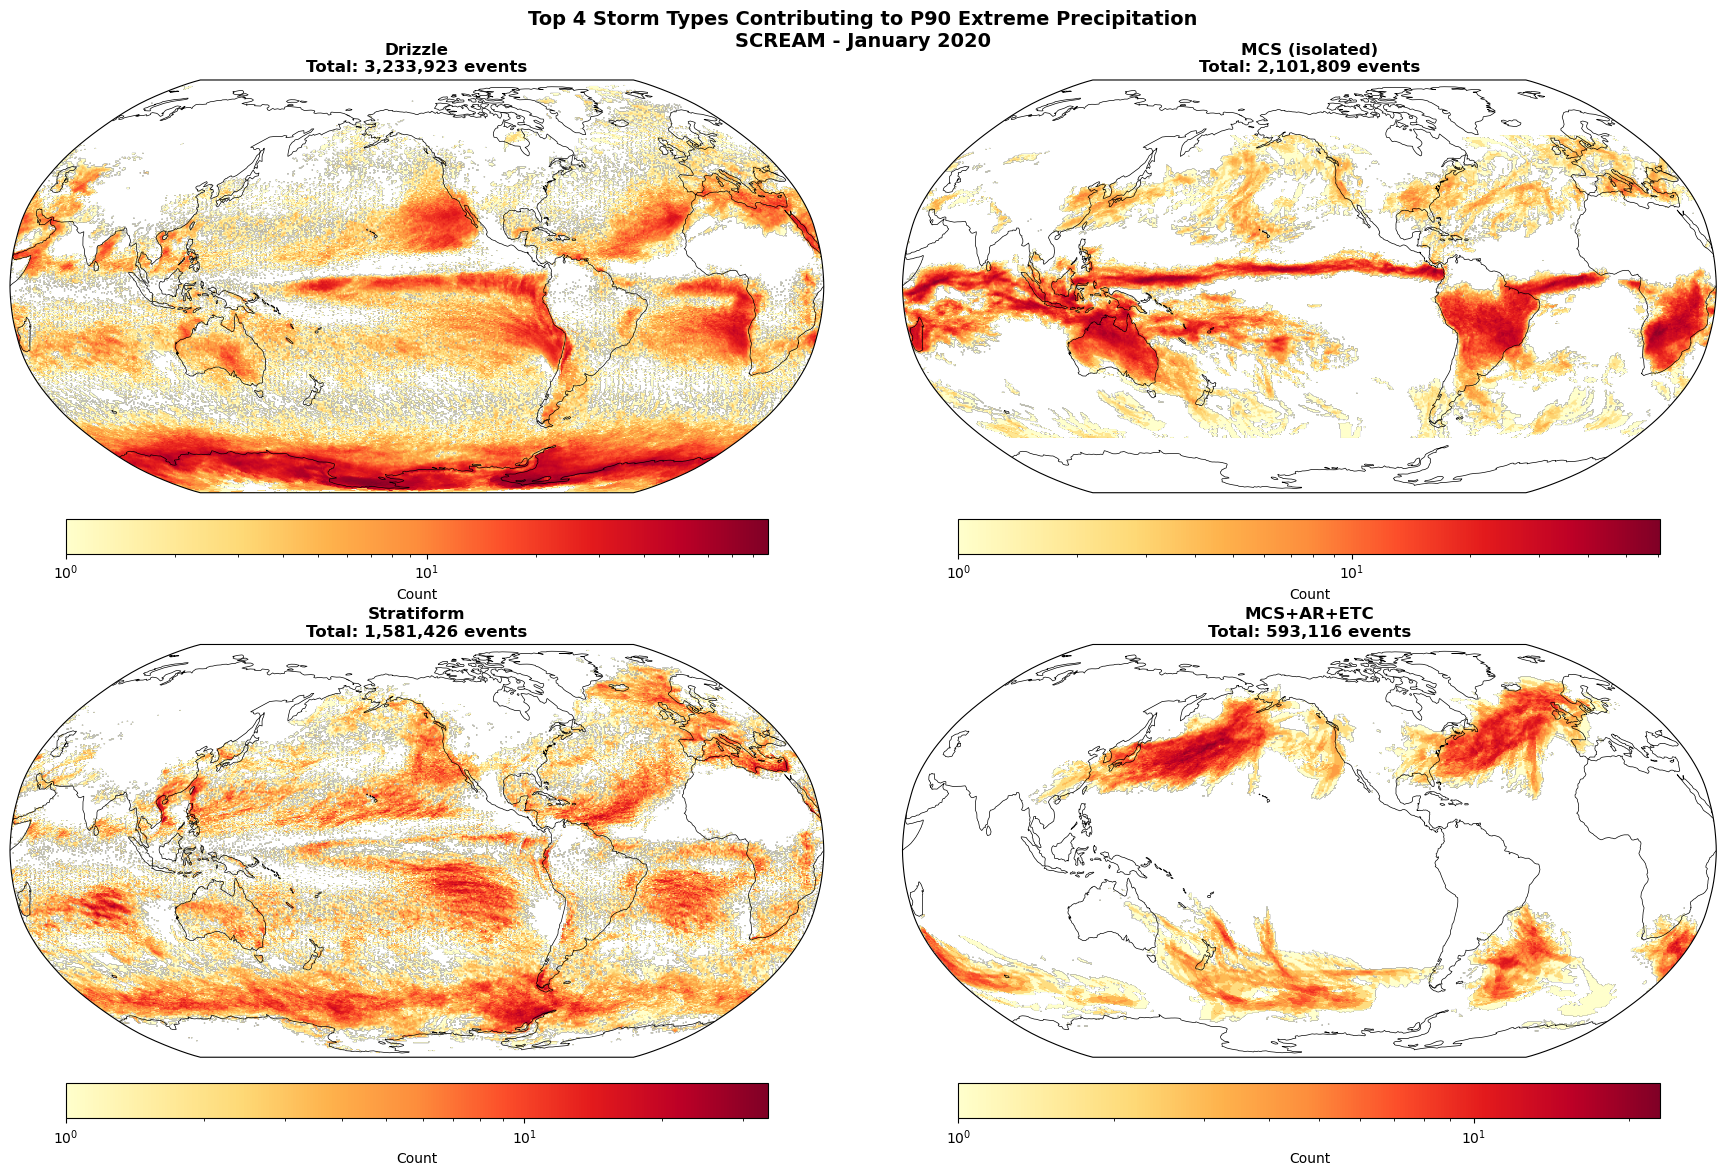

In [36]:
# Map 3: Individual storm type counts (4-panel for main contributors)
fig = plt.figure(figsize=(18, 12), dpi=100)
proj = ccrs.Robinson(central_longitude=-137)

# Select top 4 storm types based on total counts
storm_type_vars = [
    'mcs_isolated_count', 'ar_isolated_count', 'etc_isolated_count', 'tc_count',
    'mcs_ar_2way_count', 'mcs_etc_2way_count', 'ar_etc_2way_count', 'mcs_ar_etc_3way_count',
    'dc_count', 'nd_count', 'st_count', 'dz_count'
]
storm_type_labels = [
    'MCS (isolated)', 'AR (isolated)', 'ETC (isolated)', 'TC',
    'MCS+AR', 'MCS+ETC', 'AR+ETC', 'MCS+AR+ETC',
    'Deep Convection', 'Non-deep Conv', 'Stratiform', 'Drizzle'
]

# Calculate total counts for each type
totals = [(var, float(ds_spatial_p90[var].sum().values), label) 
          for var, label in zip(storm_type_vars, storm_type_labels)]
totals_sorted = sorted(totals, key=lambda x: x[1], reverse=True)

# Plot top 4
for i, (var, total, label) in enumerate(totals_sorted[:4]):
    ax = fig.add_subplot(2, 2, i+1, projection=proj)
    ax.set_global()
    ax.add_feature(cf.COASTLINE, linewidth=0.5)
    ax.set_title(f'{label}\nTotal: {int(total):,} events', fontsize=12, fontweight='bold')
    
    data = ds_spatial_p90[var].where(ds_spatial_p90[var] > 0)
    if data.max() > 0:
        im = egh.healpix_show(data, ax=ax, cmap='YlOrRd',
                              norm=mpl.colors.LogNorm(vmin=1, vmax=data.max().values.astype(int).item()))
        cbar = plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.05, shrink=0.8)
        cbar.set_label('Count', fontsize=10)

fig.suptitle(f'Top 4 Storm Types Contributing to P90 Extreme Precipitation\n{source_name.upper()} - January 2020',
             fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

In [37]:
results_p90

<xarray.Dataset> Size: 113MB
Dimensions:                (cell: 786432)
Coordinates:
    lat                    (cell) float64 6MB 0.1492 0.2984 ... -0.2984 -0.1492
    lon                    (cell) float64 6MB 45.0 45.18 44.82 ... 314.8 315.0
    time                   datetime64[ns] 8B 2020-01-01
    crs                    int64 8B 0
  * cell                   (cell) int64 6MB 0 1 2 3 ... 786429 786430 786431
Data variables: (12/15)
    total_extreme          (cell) float64 6MB dask.array<chunksize=(786432,), meta=np.ndarray>
    mcs_isolated_count     (cell) float64 6MB dask.array<chunksize=(786432,), meta=np.ndarray>
    ar_isolated_count      (cell) float64 6MB dask.array<chunksize=(786432,), meta=np.ndarray>
    etc_isolated_count     (cell) float64 6MB dask.array<chunksize=(786432,), meta=np.ndarray>
    tc_count               (cell) float64 6MB dask.array<chunksize=(786432,), meta=np.ndarray>
    mcs_ar_2way_count      (cell) float64 6MB dask.array<chunksize=(786432,), meta=np.ndarray>
    ...                     ...
    dc_count               (cell) float64 6MB dask.array<chunksize=(786432,), meta=np.ndarray>
    nd_count               (cell) float64 6MB dask.array<chunksize=(786432,), meta=np.ndarray>
    st_count               (cell) float64 6MB dask.array<chunksize=(786432,), meta=np.ndarray>
    dz_count               (cell) float64 6MB dask.array<chunksize=(786432,), meta=np.ndarray>
    unassigned_count       (cell) float64 6MB dask.array<chunksize=(786432,), meta=np.ndarray>
    dominant_type          (cell) int64 6MB dask.array<chunksize=(786432,), meta=np.ndarray>
Attributes:
    title:             Spatial distribution of extreme precipitation by storm...
    percentile:        P90
    description:       Per-cell counts of extreme precipitation occurrences b...
    ntimes_processed:  124

### Visualization: Top Contributors to Extreme Precipitation

In [38]:
# # Create a bar chart of top contributors
# fig, ax = plt.subplots(figsize=(12, 6), dpi=120)

# # Get top 10
# top_10 = df_p90.head(10)

# # Create bar chart
# bars = ax.barh(range(len(top_10)), top_10['Percentage'], color='steelblue', alpha=0.7)

# # Customize
# ax.set_yticks(range(len(top_10)))
# ax.set_yticklabels(top_10['Storm Type'])
# ax.invert_yaxis()  # Highest at top
# ax.set_xlabel('Percentage of Extreme Precipitation Events (%)', fontsize=12, fontweight='bold')
# ax.set_title(f'Top 10 Storm Types Contributing to P90 Extreme Precipitation\n{source_name.upper()} - January 2020', 
#              fontsize=14, fontweight='bold')
# ax.grid(axis='x', alpha=0.3)

# # Add percentage labels on bars
# for i, (idx, row) in enumerate(top_10.iterrows()):
#     ax.text(row['Percentage'] + 0.5, i, f"{row['Percentage']:.1f}%", 
#             va='center', fontsize=10, fontweight='bold')

# plt.tight_layout()
# plt.show()

## Aggregation Strategy for Full Year Analysis

### Recommended Approach:

For your goal of ranking dominant storm types producing extreme precipitation over a 1-year period:

**1. Multi-Threshold Analysis:**
   - Process for multiple percentiles (P90, P95, P99)
   - Compare which storm types dominate at different extremes

**2. Temporal Aggregation:**
   - Annual totals (what you get from `process_timeseries_extreme_precip`)
   - Seasonal breakdown (DJF, MAM, JJA, SON)
   - Monthly time series to identify seasonal patterns

**3. Spatial Aggregation (optional):**
   - Global statistics (current approach)
   - Regional breakdown (tropics, mid-latitudes, high-latitudes)
   - Land vs. ocean

**4. Output Format:**
   - Save aggregated counts to NetCDF with dimensions:
     - `percentile` (e.g., P90, P95, P99)
     - `storm_type` (13 categories)
     - `season` or `month` (for temporal breakdown)
   - Include percentage contributions as variables
   
**5. Comparative Analysis:**
   - Compare rankings across different data sources (observations vs. models)
   - Identify systematic biases in storm-type attribution

### Function to save results:

In [39]:
def save_spatial_stormtype_attribution(ds_spatial, output_filename, source_name, 
                                        start_date, end_date, percentile_name='P90'):
    """
    Save spatial storm type attribution results to NetCDF file.
    
    Parameters:
    -----------
    ds_spatial : xr.Dataset
        Dataset from process_timeseries_extreme_precip_spatial()
    output_filename : str
        Output NetCDF filename
    source_name : str
        Data source name
    start_date : str
        Start date of analysis period
    end_date : str
        End date of analysis period
    percentile_name : str
        Percentile name (e.g., 'P90', 'P95')
    
    Example:
    --------
    >>> ds_spatial = process_timeseries_extreme_precip_spatial(pr, pr_p90, ds, 'P90')
    >>> save_spatial_stormtype_attribution(
    ...     ds_spatial, 
    ...     'scream_stormtype_spatial_p90_2020.nc',
    ...     'scream', '2020-01-01', '2020-12-31', 'P90'
    ... )
    """
    import time
    
    # Update global attributes
    ds_spatial.attrs.update({
        'title': f'Spatial storm type attribution for {percentile_name} extreme precipitation',
        'source_name': source_name,
        'start_date': start_date,
        'end_date': end_date,
        'percentile': percentile_name,
        'created_on': time.ctime(time.time()),
        'contact': 'Zhe Feng, zhe.feng@pnnl.gov',
        'description': 'Per-cell counts of extreme precipitation occurrences by storm type. '
                      'Use dominant_type to identify which storm type contributes most to extreme precip at each location.'
    })
    
    # Set up encoding for compression
    encoding = {}
    for var in ds_spatial.data_vars:
        if 'count' in var or var == 'total_extreme':
            encoding[var] = {'dtype': 'int32', 'zlib': True, 'complevel': 4}
        elif var == 'dominant_type':
            encoding[var] = {'dtype': 'int16', 'zlib': True, 'complevel': 4}
    
    # Save to NetCDF
    ds_spatial.to_netcdf(output_filename, encoding=encoding)
    print(f"✅ Saved spatial attribution: {output_filename}")
    
    # Print summary statistics
    print(f"\nSummary Statistics:")
    print(f"  Total cells with extreme precipitation: {int((ds_spatial['total_extreme'] > 0).sum().values):,}")
    print(f"  Mean extreme precip count per cell: {float(ds_spatial['total_extreme'].mean().values):.2f}")
    print(f"  Max extreme precip count: {int(ds_spatial['total_extreme'].max().values)}")
    
    # Count dominant storm types
    print(f"\n  Dominant Storm Type Distribution:")
    storm_type_labels = [
        'MCS (iso)', 'AR (iso)', 'ETC (iso)', 'TC',
        'MCS+AR', 'MCS+ETC', 'AR+ETC', 'MCS+AR+ETC',
        'DC', 'ND', 'ST', 'DZ', 'Unassigned'
    ]
    for i, label in enumerate(storm_type_labels, start=1):
        count = int((ds_spatial['dominant_type'] == i).sum().values)
        if count > 0:
            pct = 100 * count / int((ds_spatial['dominant_type'] > 0).sum().values)
            print(f"    {label:20s}: {count:8,} cells ({pct:5.2f}%)")
    
    return ds_spatial

print("✅ save_spatial_stormtype_attribution() function defined")

✅ save_spatial_stormtype_attribution() function defined


### Example: Process Multiple Percentiles and Save Results

In [ ]:
# Example: Save spatial results for the test subset
output_file = f"{root_dir}/extreme_precip/{source_name}_stormtype_spatial_p90_202001_test.nc"

ds_saved = save_spatial_stormtype_attribution(
    ds_spatial_p90,
    output_file,
    source_name,
    '2020-01-01',
    '2020-01-31',
    percentile_name='P90'
)

print(f"\n✅ Spatial attribution saved!")
print(f"   Load later with: ds = xr.open_dataset('{output_file}')")

✅ Saved spatial attribution: /pscratch/sd/w/wcmca1/hackathon//extreme_precip/scream_stormtype_spatial_p90_202001_test.nc

Summary Statistics:
  Total cells with extreme precipitation: 659,469
  Total cells with extreme precipitation: 659,469
  Mean extreme precip count per cell: 12.52
  Mean extreme precip count per cell: 12.52
  Max extreme precip count: 89

  Dominant Storm Type Distribution:
  Max extreme precip count: 89

  Dominant Storm Type Distribution:
    MCS (iso)           :  149,067 cells (22.60%)
    MCS (iso)           :  149,067 cells (22.60%)
    AR (iso)            :    5,638 cells ( 0.85%)
    AR (iso)            :    5,638 cells ( 0.85%)
    ETC (iso)           :   14,400 cells ( 2.18%)
    ETC (iso)           :   14,400 cells ( 2.18%)
    TC                  :      482 cells ( 0.07%)
    TC                  :      482 cells ( 0.07%)
    MCS+AR              :   56,533 cells ( 8.57%)
    MCS+AR              :   56,533 cells ( 8.57%)
    MCS+ETC             :   16,726

: 

## Summary: Spatial vs Global Aggregation

### Two Complementary Approaches:

**1. Spatial Approach (NEW - for mapping):**
   - Function: `process_timeseries_extreme_precip_spatial()`
   - Returns: Dataset with per-cell counts for each storm type
   - Output dimensions: `(cell,)` - preserves spatial information
   - Use case: Create maps showing dominant storm types, regional patterns
   - Variables include:
     - `total_extreme`: count of extreme precip at each cell
     - `{stormtype}_count`: count for each storm type at each cell
     - `dominant_type`: categorical map (1-13) of dominant contributor
   
**2. Global Aggregation (original - for ranking):**
   - Function: `process_timeseries_extreme_precip()` (non-spatial version)
   - Returns: Dictionary with global totals
   - Output: Single number per storm type
   - Use case: Overall statistics, top-N ranking across entire domain
   
### Recommended Workflow for Full Year:

```python
# For each percentile (P90, P95, P99):
for pname, pthresh in [('P90', pr_p90), ('P95', pr_p95), ('P99', pr_p99)]:
    # Get spatial distribution
    ds_spatial = process_timeseries_extreme_precip_spatial(
        pr, pthresh, ds, percentile_name=pname
    )
    
    # Save for mapping
    save_spatial_stormtype_attribution(
        ds_spatial, 
        f'{source_name}_stormtype_spatial_{pname.lower()}_2020.nc',
        source_name, '2020-01-01', '2020-12-31', pname
    )
    
    # Create maps
    # - Dominant storm type map
    # - Individual storm type contribution maps
    # - Regional breakdown (tropics, mid-latitudes, etc.)
```

### Analysis Options with Spatial Data:

1. **Dominant Storm Type Maps**: Use `dominant_type` variable
2. **Contribution Intensity**: Plot `{stormtype}_count` for specific types
3. **Regional Statistics**: Aggregate by latitude bands or regions
4. **Land vs Ocean**: Mask by land/ocean and compare
5. **Model Comparison**: Compare dominant types across different models